# IMT 573 - Final Examination


Points: 100

Name: Daniel Seo

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Daniel Seo
11/23/2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

Throughout this exam, I used my previous labs as templates for some of the things that I did. 

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [48]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [49]:
print("Average respondents:", round(affairs['age'].mean(), 2))
print("children count:", affairs['children'].value_counts())
print("Average children:", round(affairs['children'].mean(), 2))                            

Average respondents: 29.08
children count: children
0.0    2414
2.0    1481
1.0    1159
3.0     781
4.0     328
5.5     203
Name: count, dtype: int64
Average children: 1.4


This data has a lot of personal data. It is about affairs so it is an uncomfortable situation and topic. It is also a bit weird that they said 5.5 children. I'm not sure what that would mean and how you can have half a child. Analyzing this type of data could also lead to some uncomfortable sitautions where you are asking talking about how things like religion or occupation or education takes into account of whether someone is likely to have an affair or not. 

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [50]:
affairs['had_affairs'] = (affairs['affairs'] > 0 ).astype(int)

affairs['affairs'].value_counts()

affairs
0.000000     4313
1.400000      118
0.583333       86
0.400000       72
1.333333       72
             ... 
3.878787        1
7.111111        1
39.199982       1
4.923077        1
57.599991       1
Name: count, Length: 77, dtype: int64

In [51]:
affairs['had_affairs'].value_counts()

had_affairs
0    4313
1    2053
Name: count, dtype: int64

The advantage of this is that you're able to make this very binary with either having an affair or not having an affair. This would be good to analyze this type of data but doesn't give us a lot of ways to explore the data more and get into more detail. If you keep it the way it was originally with how long an affair lasted, then you can dig deeper into the data.

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [52]:
X = affairs [['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ', 'occupation', 'occupation_husb']]
X = sm.add_constant(X)
Y = affairs['had_affairs']

log_model = sm.Logit(Y, X).fit()
print(log_model.summary())


Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            had_affairs   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        06:50:04   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage 

When you look at the rate_marriage section. the coef is -0.7161 which is a strong indicator that if someone rates their marriage as happy, then they have a very little chance of having an affair. The second best indicator if someone not having an affair is religious. Another part to look at is the years married. The longer you're married to more likely you are to have an affair.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [53]:
current_X = X.copy()
current_model = log_model


while True:
    p_values = current_model.pvalues.drop('const')
    max_p_value = p_values.max()
    max_p_variable = p_values.idxmax()

    if max_p_value < 0.05:
        best_model = current_model
        break

    if len(p_values) == 1:
        best_model = current_model
        break

    current_X = current_X.drop(columns=[max_p_variable])
    current_model = sm.Logit(Y, current_X).fit(disp=0)

print(best_model.summary())

print(log_model.aic)
print(current_model.aic)



                           Logit Regression Results                           
Dep. Variable:            had_affairs   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        06:50:04   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.7371      0.296     12.622      0.000       3.157       4.317
rate_marriage    -0.7153      0.031    -22.804      0.000      -0.777      -0.654
age              -0.0602      0.010     

(e) Interpret the model parameters using the model from part (d).

It looks like the current stepwise is a better model because the aic is lower. 

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

[2.30984052e-10 9.69610027e-09 4.07016516e-07 1.70851933e-05
 7.16689527e-04]


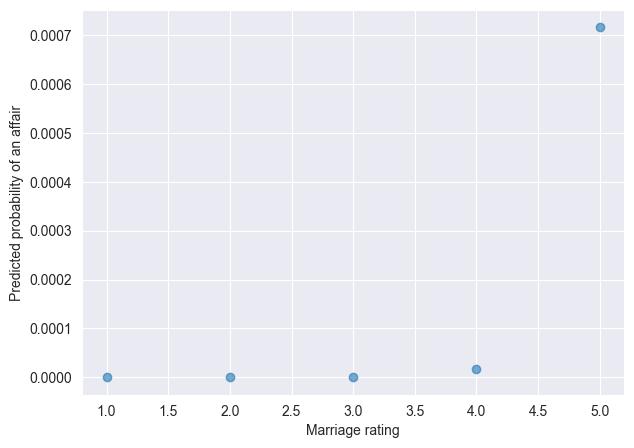

In [54]:
test_data = pd.DataFrame({
    'rate_marriage': np.arange(1, 6),
    'age': affairs['age'].mean(),
    'yrs_married': affairs['yrs_married'].mean(),
    'religious': affairs['religious'].mean(),
    'educ': affairs['educ'].mean(),
    'occupation': affairs['occupation'].mean(),
    'occupation_husb': affairs['occupation_husb'].mean()
})

test_data = sm.add_constant(test_data)

predicted_probs = current_model.predict(test_data)

print(predicted_probs.values)


plt.figure(figsize=(7,5))
plt.scatter(test_data['rate_marriage'], predicted_probs , alpha = 0.6)
plt.xlabel('Marriage rating')
plt.ylabel('Predicted probability of an affair')
plt.show()



    

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

I think I went wrong somewhere but I have no idea how to find out what I did wrong. I used my other assignments to see how to do the predictions but it seems to not be working properly. I think there's something wrong with my stepwise step.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [55]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

I want to see how someone's performance (batting average) is and how it determines their salary. If someone has a certain batting average, what should their salary be?

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

The data shows players and their baseball stats and their salary. There are some salary stats that are missing and it generally looks like it's players in their 1st year.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

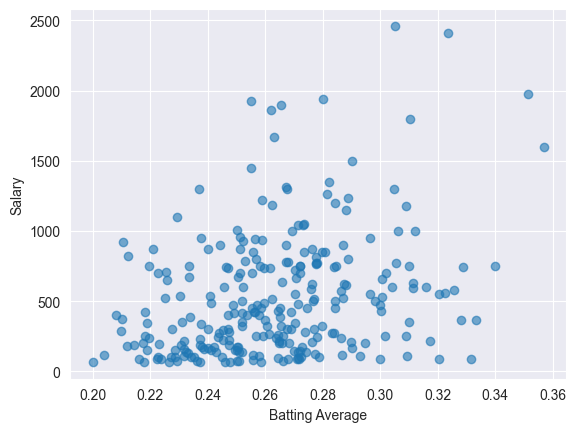

In [56]:
Hitters = Hitters[Hitters['Salary'].notna()]
Hitters['batting_avg'] = (Hitters['Hits'] / Hitters['AtBat'])
Hitters = Hitters[Hitters['batting_avg'] > 0.1]

plt.scatter(Hitters['batting_avg'], Hitters['Salary'], alpha=0.6)
plt.xlabel('Batting Average')
plt.ylabel('Salary')
plt.show()

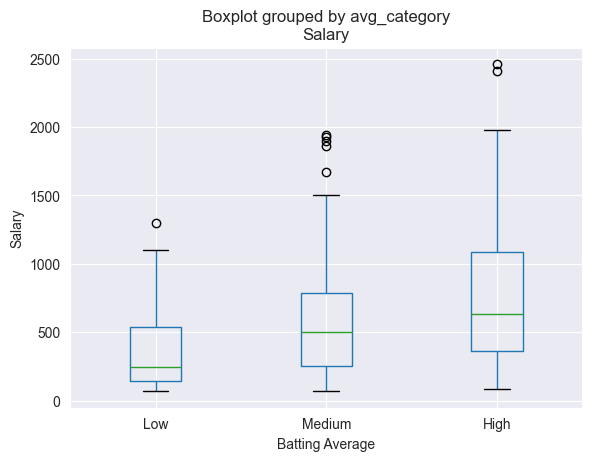

In [57]:
Hitters['avg_category'] = pd.cut(Hitters['batting_avg'], bins=3, labels = ['Low', 'Medium', 'High'])
Hitters.boxplot(column='Salary', by='avg_category')
plt.xlabel('Batting Average')
plt.ylabel('Salary')
plt.show()

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

I was able to answer my question based off of this data. Essentially it shows that the better of a player you are, the higher your salary. This shows in both the scatter plot and the box plot that shows that generally this is true.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [58]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

In [59]:
print(df[['age', 'bmi', 'children', 'charges']].corr())

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


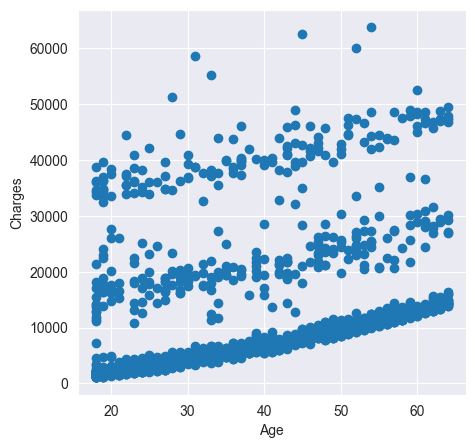

In [60]:
plt.figure(figsize=(5,5))
plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

This is an interesting graph because it shows that older generation tend to have more charges than younger. This makes sense if this is a running total.

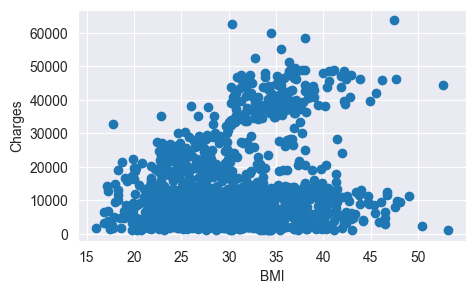

In [61]:
plt.figure(figsize=(5,3))
plt.scatter(df['bmi'], df['charges'])
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

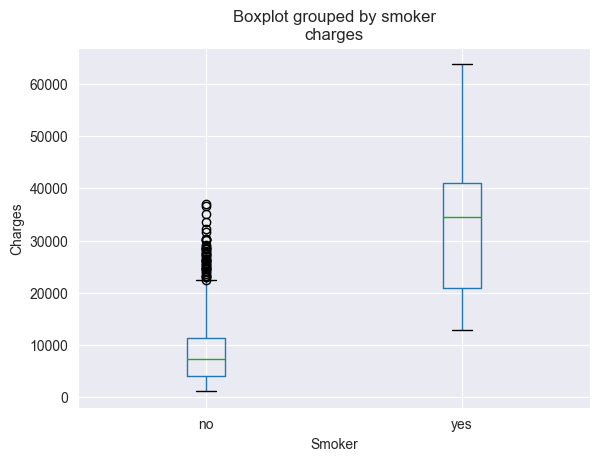

In [62]:
df.boxplot(column='charges', by='smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

This is interesting in that it shows that if there is a crime then it is more likely that the person is a smoker

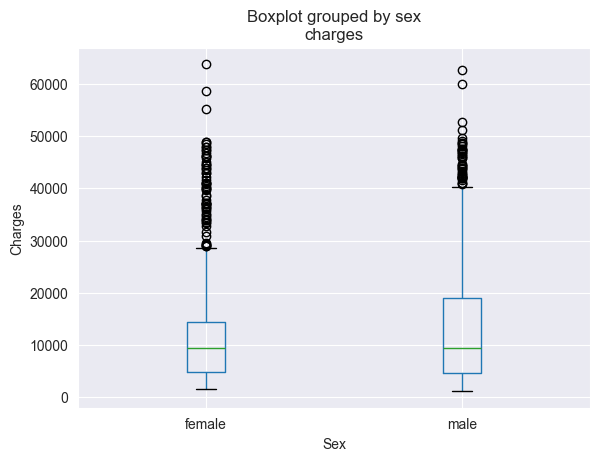

In [63]:
df.boxplot(column='charges', by='sex')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [64]:
X3 = df[['age', 'bmi', 'children']]
Y3 = df['charges']

X3 = sm.add_constant(X3)

bmi_model = sm.OLS(Y3, X3).fit()

print(bmi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.69
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           8.80e-37
Time:                        06:50:04   Log-Likelihood:                -14392.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1334   BIC:                         2.881e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6916.2433   1757.480     -3.935      0.0

In [65]:
x_bmi = sm.add_constant(df[['bmi']])
model_bmi = sm.OLS(Y3, x_bmi).fit()

print(model_bmi.rsquared * 100)

3.933913991786264


BMI only shows about a 3.9% variance in charges.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

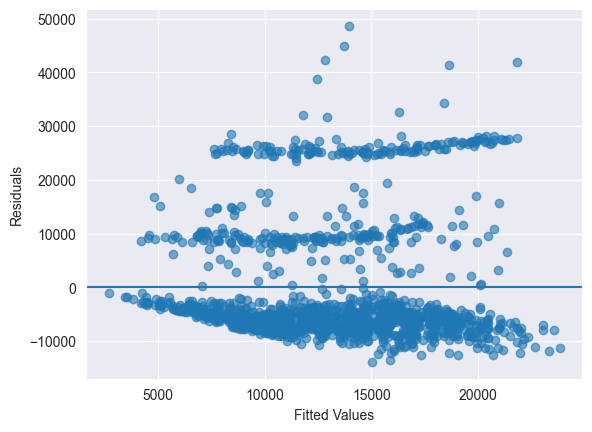

In [66]:
residuals = bmi_model.resid

plt.scatter(bmi_model.fittedvalues, residuals, alpha = 0.6)
plt.axhline(y=0)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

It looks like a majority of the points are showing a negative residual.

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [67]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

In [68]:
url = location + dataframe
tumors = pd.read_csv(url, header=None)
column_names = [
    'Sample_code_number', 
    'Clump_thickness', 
    'Uniformity_of_cell_size', 
    'Uniformity_of_cell_shape', 
    'Marginal_adhesion', 
    'Single_epithelial_cell_size', 
    'Bare_nuclei', 
    'Bland_chromatin', 
    'Normal_nucleoli', 
    'Mitoses',
    'Class'
    ]
tumors.columns = column_names
tumors['Sample_code_number'] = tumors['Sample_code_number'].astype('category')
tumors['Bare_nuclei'] = pd.to_numeric(tumors['Bare_nuclei'], errors = 'coerce')
tumors = tumors.dropna()
tumors['Bare_nuclei'] = tumors['Bare_nuclei'].astype(int)
tumors.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

there was some data missing that I needed to drop in order to get Bare_nuclei to work as a integer

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [69]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(tumors, test_size = 0.3, random_state = 27)

train.shape[0]

#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

478

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

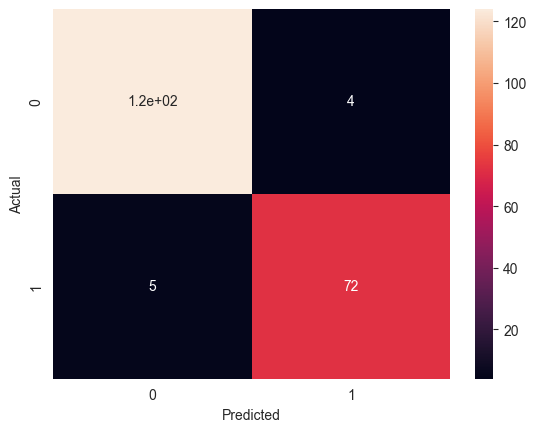

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

x_train = train.drop(['Sample_code_number', 'Class'], axis=1)
y_train = train['Class']
x_test = test.drop(['Sample_code_number', 'Class'], axis=1)
y_test = test['Class']

lin_model = LogisticRegression()
lin_model.fit(x_train, y_train)
y_predict = lin_model.predict(x_test)


confusion = confusion_matrix(y_test, y_predict)


sns.heatmap(confusion, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# reference https://seaborn.pydata.org/generated/seaborn.heatmap.html
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

This has a pretty good prediction model. The most concerning is the 5 in the section where it is the False Negatives

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

The first one that comes to mind is determining if something is Spam or not for emails. If done correctly, then spam will go into the spam folder.

Another one would be something like the tumor predictor. Is it a tumor or is it not? I think this could be used for other medical diagnosis. I think the dataset would have to be something a bit more definitive than what we have here.

Lastly, financial institutions could use something for mortgage loan approval or denial. 

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

There is a lot of opportunity to use regression models. One would be to use it for house price predictions. Based on certain market data or economic data, you could predict how a house's price would increase or decrease. 

Another one would be medical cost predictions. This could show that based on someone's medical stats, their projected lifetime medical costs. The dataset we worked with would be a good start to see what costs would be. We could dig in deeper and discover additional variables to take into account with our model.

Lastly, we could try to use it on stock prices. Using historical data and market fluctuations, we could try to predict what the market will do. Although there will be many variables, it is theortically possible to do it.

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

Flexible models alllow you to train models better and being able to use larger datasets to make better predictions. However sometimes there could be issues with the data not really working out but the model tries its best to fit a square peg into a round hole.

Flexible models would be better to use if you have a larger data set and you're using it for predictions and not trying to get real answers from it.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

The answer is 

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

Salary = 50 + 20(4.0) + 0.07(110) + 35(1) + 0.01(4.0 * 110) - (10(4.0 * 1))
Salary = 137.1 thousand dollars

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

False. I'm just taking a guess here.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  